# Cross-Validation (Validacion Cruzada)

**Problema:** Las metricas como R2 y RMSE calculadas sobre los mismos datos de entrenamiento pueden ser **optimistas**. Como sabemos si el modelo realmente generaliza?

**Solucion:** No evaluar el modelo con los datos que ya vio. Usar datos "nuevos" (holdout).

**Cross-validation** lleva esta idea al extremo: divide los datos en **k partes** y rota cual es el holdout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    cross_val_predict,
)
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/housing.csv", index_col="id")
predictors = ["square_meters", "age", "distance_to_center_km"]
outcome = "price"

X = df[predictors]
y = df[outcome]
print(f"Dataset: {len(df)} registros, {len(predictors)} predictores")
df.head()

Dataset: 100 registros, 3 predictores


,square_meters,age,price,bedrooms,bathrooms,floor,distance_to_center_km,has_garage,build_quality
id,,,,,,,,,
1,51,5,152700,2,1,2,4.7,0,5
2,52,44,132300,2,1,10,4.3,1,3
3,56,36,183200,2,1,1,6.6,1,6
4,57,6,170100,3,2,8,14.0,1,5
5,58,21,109500,2,1,1,18.0,1,5


---
## 1. El problema del holdout simple

Un solo train/test split puede ser **inestable** con pocos datos. Veamos cuanto varia el RMSE solo por cambiar el split.

In [3]:
results = []
for seed in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    model = LinearRegression().fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({"seed": seed, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print(
    f"\nRMSE varia entre ${results_df['RMSE'].min():,.0f} y ${results_df['RMSE'].max():,.0f}"
)
print(f"Esa variacion es solo por cambiar que 20% queda como test.")

 seed         RMSE       R2
    0 36687.881188 0.861409
    1 39357.001978 0.752801
    2 32362.480516 0.853547
    3 39875.864417 0.788633
    4 43738.676572 0.762442
    5 41854.274732 0.638955
    6 42902.697942 0.611447
    7 36654.870254 0.798982
    8 36040.125517 0.847301
    9 39353.301575 0.719915

RMSE varia entre $32,362 y $43,739
Esa variacion es solo por cambiar que 20% queda como test.


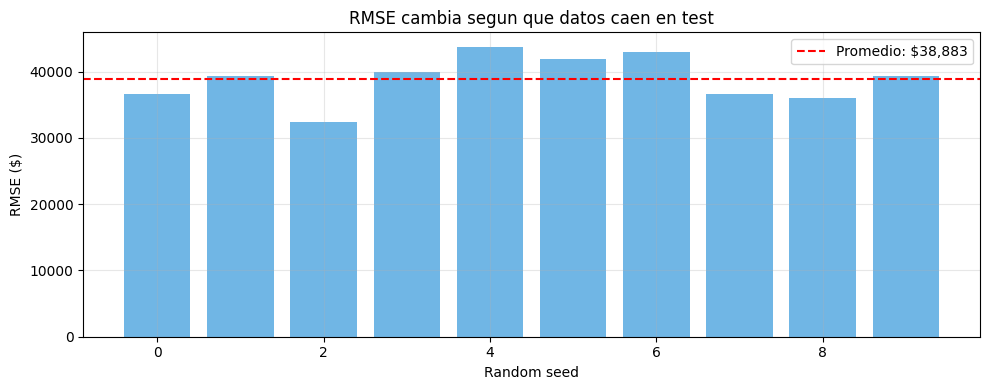

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(results_df["seed"], results_df["RMSE"], color="#3498db", alpha=0.7)
ax.axhline(
    results_df["RMSE"].mean(),
    color="red",
    linestyle="--",
    label=f"Promedio: ${results_df['RMSE'].mean():,.0f}",
)
ax.set_xlabel("Random seed")
ax.set_ylabel("RMSE ($)")
ax.set_title("RMSE cambia segun que datos caen en test")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. K-Fold Cross-Validation: la idea

En vez de depender de **un solo split**, dividimos los datos en `k` partes (folds):

```
Fold 1: [TEST] [train] [train] [train] [train]
Fold 2: [train] [TEST] [train] [train] [train]
Fold 3: [train] [train] [TEST] [train] [train]
Fold 4: [train] [train] [train] [TEST] [train]
Fold 5: [train] [train] [train] [train] [TEST]
```

Cada dato es test **exactamente una vez**. Promediamos los resultados.

---
## 3. K-Fold a mano (para entenderlo)

In [7]:
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

rmse_scores = []
r2_scores = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = LinearRegression().fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(
        f"Fold {fold}: train={len(train_idx)}, test={len(test_idx)} | RMSE=${rmse:,.0f} | R2={r2:.4f}"
    )

print(f"\n--- Promedio ---")
print(f"RMSE: ${np.mean(rmse_scores):,.0f} +/- ${np.std(rmse_scores):,.0f}")
print(f"R2:   {np.mean(r2_scores):.4f} +/- {np.std(r2_scores):.4f}")

Fold 1: train=80, test=20 | RMSE=$36,795 | R2=0.7791
Fold 2: train=80, test=20 | RMSE=$37,597 | R2=0.8305
Fold 3: train=80, test=20 | RMSE=$34,855 | R2=0.7651
Fold 4: train=80, test=20 | RMSE=$46,967 | R2=0.6831
Fold 5: train=80, test=20 | RMSE=$44,808 | R2=0.7701

--- Promedio ---
RMSE: $40,204 +/- $4,774
R2:   0.7656 +/- 0.0474


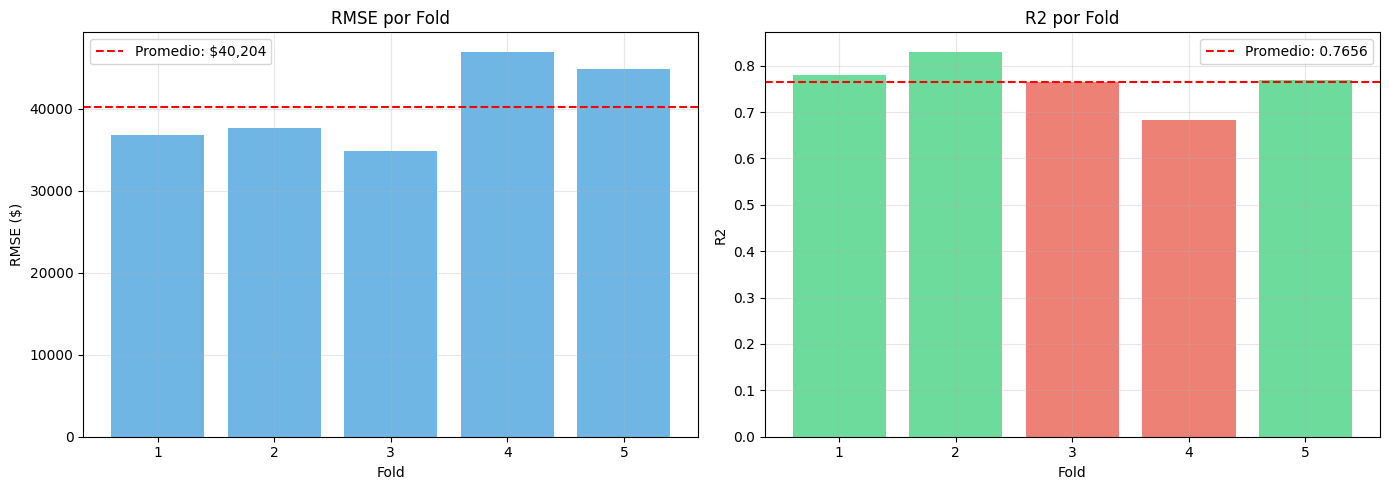

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

folds = range(1, k + 1)
colors = ["#2ecc71" if r > np.mean(r2_scores) else "#e74c3c" for r in r2_scores]

axes[0].bar(folds, rmse_scores, color="#3498db", alpha=0.7)
axes[0].axhline(
    np.mean(rmse_scores),
    color="red",
    linestyle="--",
    label=f"Promedio: ${np.mean(rmse_scores):,.0f}",
)
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("RMSE ($)")
axes[0].set_title("RMSE por Fold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(folds, r2_scores, color=colors, alpha=0.7)
axes[1].axhline(
    np.mean(r2_scores),
    color="red",
    linestyle="--",
    label=f"Promedio: {np.mean(r2_scores):.4f}",
)
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("R2")
axes[1].set_title("R2 por Fold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. K-Fold con sklearn (forma rapida)

`cross_val_score` hace todo lo anterior en una linea.

In [9]:
model = LinearRegression()

# scoring="neg_mean_squared_error" porque sklearn usa convencion de "mayor = mejor"
mse_scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
rmse_scores_sk = np.sqrt(-mse_scores)

r2_scores_sk = cross_val_score(model, X, y, cv=5, scoring="r2")

print(f"RMSE por fold: {['${:,.0f}'.format(s) for s in rmse_scores_sk]}")
print(f"RMSE promedio: ${rmse_scores_sk.mean():,.0f} +/- ${rmse_scores_sk.std():,.0f}")
print(f"\nR2 por fold:   {[f'{s:.4f}' for s in r2_scores_sk]}")
print(f"R2 promedio:   {r2_scores_sk.mean():.4f} +/- {r2_scores_sk.std():.4f}")

RMSE por fold: ['$28,043', '$31,516', '$47,991', '$47,661', '$41,879']
RMSE promedio: $39,418 +/- $8,238

R2 por fold:   ['0.3602', '0.4086', '0.4676', '0.0079', '0.3898']
R2 promedio:   0.3268 +/- 0.1633


---
## 5. Cuantos folds? k=5 vs k=10 vs LOO

| k | Nombre | Train size | Test size | Trade-off |
|---|--------|-----------|-----------|----------|
| 5 | 5-Fold | 80% | 20% | Buen balance general |
| 10 | 10-Fold | 90% | 10% | Menos sesgo, mas varianza |
| n | LOO (Leave-One-Out) | n-1 | 1 | Minimo sesgo, maxima varianza |

In [10]:
model = LinearRegression()
k_values = [3, 5, 10, 20, len(X)]  # len(X) = Leave-One-Out

comparison = []
for k in k_values:
    scores = cross_val_score(model, X, y, cv=k, scoring="neg_mean_squared_error")
    rmses = np.sqrt(-scores)
    name = f"LOO (k={k})" if k == len(X) else f"k={k}"
    comparison.append(
        {
            "k": name,
            "RMSE_mean": f"${rmses.mean():,.0f}",
            "RMSE_std": f"${rmses.std():,.0f}",
        }
    )

pd.DataFrame(comparison)

,k,RMSE_mean,RMSE_std
0,k=3,"$38,910","$7,447"
1,k=5,"$39,418","$8,238"
2,k=10,"$38,815","$11,095"
3,k=20,"$37,506","$15,284"
4,LOO (k=100),"$30,954","$26,331"


---
## 6. Caso practico: comparar modelos con cross-validation

Antes comparamos modelos con un solo split. Ahora hagamoslo **bien** con CV.

In [11]:
predictor_sets = {
    "solo m2": ["square_meters"],
    "m2 + age": ["square_meters", "age"],
    "m2 + age + distancia": ["square_meters", "age", "distance_to_center_km"],
    "todos": [
        "square_meters",
        "age",
        "bedrooms",
        "bathrooms",
        "floor",
        "distance_to_center_km",
        "has_garage",
        "build_quality",
    ],
}

cv_results = []
for name, preds in predictor_sets.items():
    model = LinearRegression()
    mse = cross_val_score(model, df[preds], y, cv=5, scoring="neg_mean_squared_error")
    rmse = np.sqrt(-mse)
    r2 = cross_val_score(model, df[preds], y, cv=5, scoring="r2")
    cv_results.append(
        {
            "Modelo": name,
            "Predictores": len(preds),
            "RMSE (CV)": f"${rmse.mean():,.0f} +/- ${rmse.std():,.0f}",
            "R2 (CV)": f"{r2.mean():.4f} +/- {r2.std():.4f}",
        }
    )

pd.DataFrame(cv_results)

,Modelo,Predictores,RMSE (CV),R2 (CV)
0,solo m2,1,"$43,888 +/- $7,114",0.1587 +/- 0.1351
1,m2 + age,2,"$42,544 +/- $6,318",0.2002 +/- 0.1601
2,m2 + age + distancia,3,"$39,418 +/- $8,238",0.3268 +/- 0.1633
3,todos,8,"$39,018 +/- $9,908",0.3521 +/- 0.1703


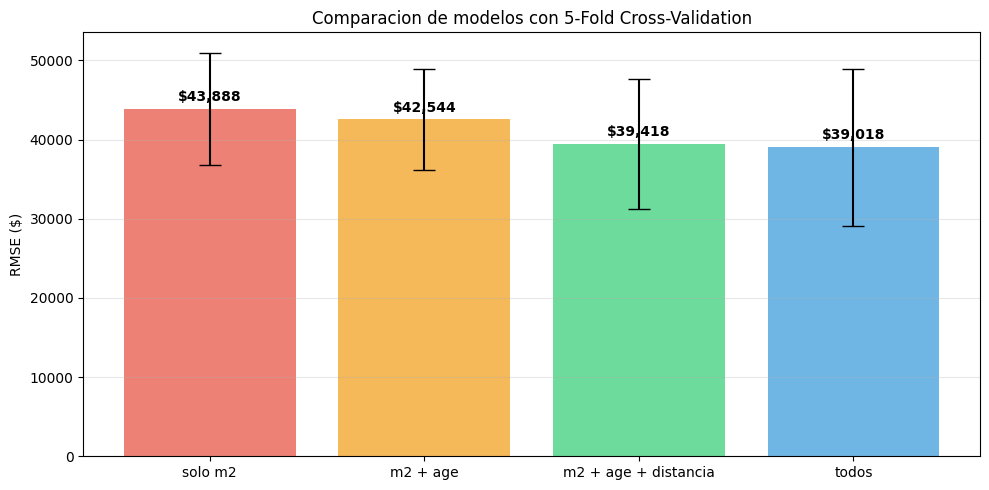

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

names = list(predictor_sets.keys())
means = []
stds = []
for preds in predictor_sets.values():
    mse = cross_val_score(
        LinearRegression(), df[preds], y, cv=5, scoring="neg_mean_squared_error"
    )
    rmse = np.sqrt(-mse)
    means.append(rmse.mean())
    stds.append(rmse.std())

colors = ["#e74c3c", "#f39c12", "#2ecc71", "#3498db"]
bars = ax.bar(names, means, yerr=stds, capsize=8, color=colors, alpha=0.7)
ax.set_ylabel("RMSE ($)")
ax.set_title("Comparacion de modelos con 5-Fold Cross-Validation")
ax.grid(True, alpha=0.3, axis="y")

for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f"${mean:,.0f}",
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

---
## 7. Visualizar predicciones de CV

`cross_val_predict` da la prediccion de cada dato **cuando era parte del test**.

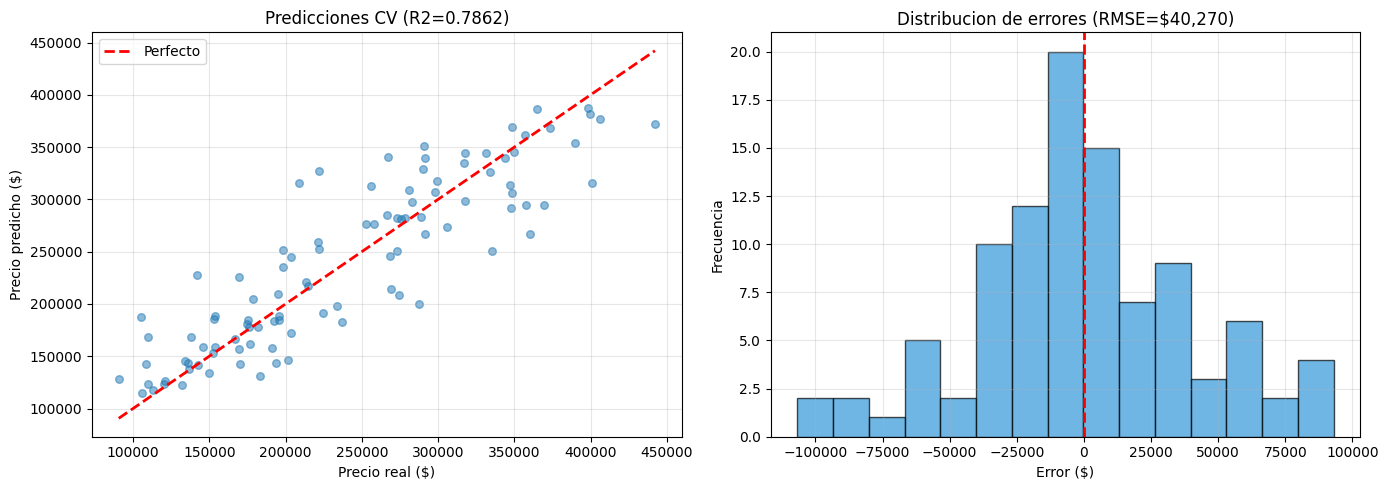

In [16]:
model = LinearRegression()
y_pred_cv = cross_val_predict(model, X, y, cv=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicho vs Real
axes[0].scatter(y, y_pred_cv, alpha=0.5, s=30)
min_val, max_val = y.min(), y.max()
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfecto")
axes[0].set_xlabel("Precio real ($)")
axes[0].set_ylabel("Precio predicho ($)")
axes[0].set_title(f"Predicciones CV (R2={r2_score(y, y_pred_cv):.4f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribucion de errores
errors = y - y_pred_cv
axes[1].hist(errors, bins=15, color="#3498db", alpha=0.7, edgecolor="black")
axes[1].axvline(0, color="red", linestyle="--", lw=2)
axes[1].set_xlabel("Error ($)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title(
    f"Distribucion de errores (RMSE=${np.sqrt(mean_squared_error(y, y_pred_cv)):,.0f})"
)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. In-sample vs Out-of-sample: la diferencia clave

In [17]:
model = LinearRegression().fit(X, y)
y_pred_insample = model.predict(X)

r2_insample = r2_score(y, y_pred_insample)
rmse_insample = np.sqrt(mean_squared_error(y, y_pred_insample))

r2_cv = r2_score(y, y_pred_cv)
rmse_cv = np.sqrt(mean_squared_error(y, y_pred_cv))

comparison_df = pd.DataFrame(
    [
        {
            "Metodo": "In-sample (entrena y evalua con TODO)",
            "R2": f"{r2_insample:.4f}",
            "RMSE": f"${rmse_insample:,.0f}",
        },
        {
            "Metodo": "Cross-validation (5-fold)",
            "R2": f"{r2_cv:.4f}",
            "RMSE": f"${rmse_cv:,.0f}",
        },
    ]
)
print(comparison_df.to_string(index=False))
print(f"\nEl in-sample es mas optimista porque el modelo ya 'vio' esos datos.")
print(f"Cross-validation da una estimacion mas honesta del rendimiento real.")

                               Metodo     R2    RMSE
In-sample (entrena y evalua con TODO) 0.7987 $39,077
            Cross-validation (5-fold) 0.7862 $40,270

El in-sample es mas optimista porque el modelo ya 'vio' esos datos.
Cross-validation da una estimacion mas honesta del rendimiento real.


---
## Resumen

| Concepto | Que es | Cuando usarlo |
|----------|--------|---------------|
| **Holdout simple** | Un solo train/test split | Rapido, pero inestable con pocos datos |
| **K-Fold CV** | K rotaciones de train/test | Evaluacion robusta, el estandar |
| **LOO** | K = n (cada dato es test una vez) | Datasets muy pequenos |
| **In-sample** | Evaluar con datos de entrenamiento | Nunca para evaluar, siempre es optimista |

**Regla de oro:** siempre evalua con datos que el modelo **no vio** durante el entrenamiento.